In [16]:
import pandas as pd
import numpy as np
import os
import glob
import mudata as md
import anndata as ad
import seaborn as sns
from scipy.stats import norm
import matplotlib.pyplot as plt

In [20]:
data_dir = "/data/pinello/SHARED_DATA/genome_wide_Perturb-seq/"
results_files = glob.glob(f"{data_dir}/*.results.csv.gz")
results_files

['/data/pinello/SHARED_DATA/genome_wide_Perturb-seq/K562_gwps_raw_singlecell.chunk_00.results.csv.gz',
 '/data/pinello/SHARED_DATA/genome_wide_Perturb-seq/K562_gwps_raw_singlecell.chunk_01.results.csv.gz',
 '/data/pinello/SHARED_DATA/genome_wide_Perturb-seq/K562_gwps_raw_singlecell.chunk_03.results.csv.gz',
 '/data/pinello/SHARED_DATA/genome_wide_Perturb-seq/K562_gwps_raw_singlecell.chunk_02.results.csv.gz']

In [44]:
adata = md.read(f"{data_dir}/K562_gwps_raw_singlecell_01.h5ad")
adata

KeyboardInterrupt: 

In [ ]:
adata.var

In [21]:
scpower_df = pd.concat(pd.read_csv(f, index_col=0) for f in results_files).reset_index(drop=True)
scpower_df

,element,gene,z_value,p_value
0,A1BG_+_58858964.23-P1|A1BG_-_58858788.23-P1,LINC01409,0.060258,0.951950
1,A1BG_-_58864840.23-P2|A1BG_-_58864822.23-P2,LINC01409,0.333119,0.739044
2,AAAS_-_53715438.23-P1P2|AAAS_+_53715355.23-P1P2,LINC01409,-0.564344,0.572520
3,AACS_+_125549983.23-P1P2|AACS_-_125550169.23-P1P2,LINC01409,-0.393563,0.693904
4,AAED1_-_99417574.23-P1P2|AAED1_+_99417525.23-P1P2,LINC01409,-0.285259,0.775446
...,...,...,...,...
92315119,non-targeting_03756|non-targeting_01543,E2F4,0.131651,0.895260
92315120,non-targeting_03758|non-targeting_00493,E2F4,-0.323072,0.746640
92315121,non-targeting_03778|non-targeting_00397,E2F4,0.664370,0.506453
92315122,non-targeting_03783|non-targeting_02098,E2F4,-0.714036,0.475205


In [46]:
gene_counts = scpower_df.query("element == 'A1BG_+_58858964.23-P1|A1BG_-_58858788.23-P1'").value_counts('gene')
duped_genes = gene_counts[gene_counts>1].index
duped_genes

Index(['TBCE', 'HSPA14'], dtype='object', name='gene')

In [48]:
perturb_z_scores = scpower_df[~scpower_df['gene'].isin(duped_genes)].pivot(
    index = 'element',
    columns = "gene",
    values = "z_value"
)
perturb_z_scores

gene,A1BG,AAAS,AACS,AAGAB,AAK1,AAMDC,AAMP,AAR2,AARS,AARS2,...,ZSWIM8,ZUP1,ZW10,ZWILCH,ZWINT,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1
element,,,,,,,,,,,,,,,,,,,,,
A1BG_+_58858964.23-P1|A1BG_-_58858788.23-P1,-4.858475,-0.413323,-0.090301,-0.159479,0.204934,0.020590,-0.284374,0.385869,0.108473,0.006306,...,-0.116299,-0.216151,0.361042,-0.513300,0.223904,-0.157629,0.132273,-0.075873,0.459117,0.260340
A1BG_-_58864840.23-P2|A1BG_-_58864822.23-P2,-0.857826,0.044415,0.196779,-0.152471,-0.195639,-0.036245,0.066869,-0.089706,-0.150540,-0.003615,...,0.105531,-0.309220,0.077046,-0.234597,-0.196450,0.235835,-0.085493,-0.035720,0.156122,-0.035859
AAAS_-_53715438.23-P1P2|AAAS_+_53715355.23-P1P2,0.180730,-8.940343,0.381067,0.045624,-0.074102,-0.203393,0.184953,-0.288324,0.334307,0.122485,...,-0.035737,-0.220429,-0.240243,-0.327299,-0.040346,-0.139955,-0.056259,-0.335908,-0.299898,0.124672
AACS_+_125549983.23-P1P2|AACS_-_125550169.23-P1P2,0.620720,0.052509,-3.469460,-0.500040,-0.455123,-0.121393,-0.454898,0.151586,0.394634,-0.348471,...,0.061717,-0.167130,-0.345776,0.126735,0.249465,0.256970,0.187508,0.353168,-0.004968,-0.523879
AAED1_-_99417574.23-P1P2|AAED1_+_99417525.23-P1P2,-0.687399,0.813368,0.051722,0.331263,0.560532,-0.072710,-0.179703,0.145803,0.013179,-0.315434,...,0.351290,0.326943,0.124344,-0.712857,-0.364562,0.041397,0.802590,0.213683,-0.077665,0.278699
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
non-targeting_03756|non-targeting_01543,-0.053579,-0.108824,0.169367,0.516817,0.214954,-0.305058,-0.200622,-0.167826,0.000807,-0.186227,...,0.252886,0.354322,-0.012482,0.387375,0.038297,-0.144637,0.161586,0.127318,0.161940,-0.155511
non-targeting_03758|non-targeting_00493,-0.029692,-0.626282,0.350013,-0.321651,0.046052,0.080513,-0.097621,-0.077306,0.067608,-0.027054,...,-0.040042,0.109648,0.253741,-0.095654,0.428481,0.101779,0.213369,-0.392474,-0.094760,-0.305294
non-targeting_03778|non-targeting_00397,0.386458,-0.096042,0.090753,1.133987,-0.182851,0.209065,-0.913607,0.355319,-0.007213,-0.051759,...,-0.246842,0.045204,0.356567,0.662129,0.318386,-0.072407,0.142029,0.094597,-0.079842,0.007031


In [ ]:
perturb_z_scores

In [24]:
len(scpower_df)

92315124

In [3]:
!ls ${data_dir}

00_preprocess_gwps.ipynb  02_analyze_gwps_results.ipynb
01_perturbo_K562_gwps.py  gwps.ipynb


## Cluster perturbations by effect vectors

In [53]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
zdata=ad.AnnData(perturb_z_scores)
zdata

AnnData object with n_obs × n_vars = 11187 × 8244

[0.08905892 0.0648172 ]


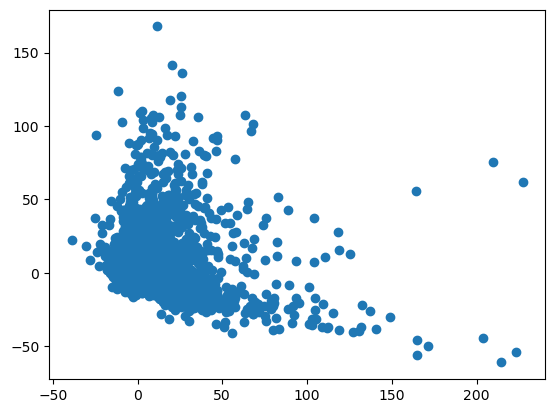

In [54]:
# zdata = ad.AnnData(perturb_z_scores, obs=mdata['grna'].var, var=mdata['rna'].var)
# tsne = TSNE(n_components=2)
# tsne_results = tsne.fit_transform(perturb_z_scores)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(perturb_z_scores)
pca_result
print(pca.explained_variance_ratio_)
fig, ax = plt.subplots()
# ax = fig.add_subplot(projection='3d')
ax.scatter(pca_result[:,0], pca_result[:,1])

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 11187 samples in 0.048s...
[t-SNE] Computed neighbors for 11187 samples in 4.365s...
[t-SNE] Computed conditional probabilities for sample 1000 / 11187
[t-SNE] Computed conditional probabilities for sample 2000 / 11187
[t-SNE] Computed conditional probabilities for sample 3000 / 11187
[t-SNE] Computed conditional probabilities for sample 4000 / 11187
[t-SNE] Computed conditional probabilities for sample 5000 / 11187
[t-SNE] Computed conditional probabilities for sample 6000 / 11187
[t-SNE] Computed conditional probabilities for sample 7000 / 11187
[t-SNE] Computed conditional probabilities for sample 8000 / 11187
[t-SNE] Computed conditional probabilities for sample 9000 / 11187
[t-SNE] Computed conditional probabilities for sample 10000 / 11187
[t-SNE] Computed conditional probabilities for sample 11000 / 11187
[t-SNE] Computed conditional probabilities for sample 11187 / 11187
[t-SNE] Mean sigma: 9.653694
[t-SNE] KL divergence

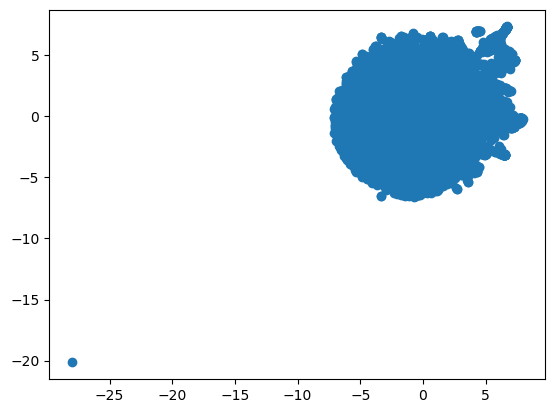

In [55]:
tsne = TSNE(n_components=2, verbose=1)
tsne_result = tsne.fit_transform(perturb_z_scores)
fig, ax = plt.subplots()
# ax = fig.add_subplot(projection='3d')
ax.scatter(tsne_result[:,0], tsne_result[:,1])


In [25]:
# def make_long_df(mat, value_name):
#     return (
#         pd.DataFrame(data=mat, columns=mdata['rna'].var['gene_name'], index=mdata['grna'].var['target'])
#         .melt(var_name="gene", value_name=value_name, ignore_index=False)
#         .reset_index(names="guide")
#     )

# # gwps_df = pd.merge(
# #     make_long_df(perturb_z_scores, "z_value"),
# #     make_long_df(perturb_p_vals, "p_value"),
# # )

# gwps_df=make_long_df(perturb_z_scores, "z_value")

In [59]:
gwps_df = scpower_df
perturb_z_score_df = perturb_z_scores

In [60]:
# perturb_z_score_df =  pd.DataFrame(data=perturb_z_scores, columns=mdata['rna'].var['gene_name'], index=mdata['grna'].var['target'])
# perturb_z_score_df

TO DO: look at gene expression distribution of HVGs

In [ ]:
n_plot_genes = 500
n_plot_perts = 50
gene_var = perturb_z_scores.std(axis=0).argsort()
hvg_idxs = gene_var[-n_plot_genes:]
plot_z_df = perturb_z_score_df.iloc[:,hvg_idxs]

pert_var = perturb_z_scores.std(axis=1).argsort()
hvp_idxs = pert_var[-n_plot_perts:]
plot_z_df = plot_z_df.iloc[hvp_idxs,:]


In [76]:
from scipy.spatial.distance import pdist, squareform
corr = np.corrcoef(plot_z_df)
# corr = squareform(pdist(perturb_z_scores, "cosine"))
corr_df = pd.DataFrame(data=corr,
                     columns=plot_z_df.index,
                     index=plot_z_df.index)

In [77]:
!pip install fastcluster

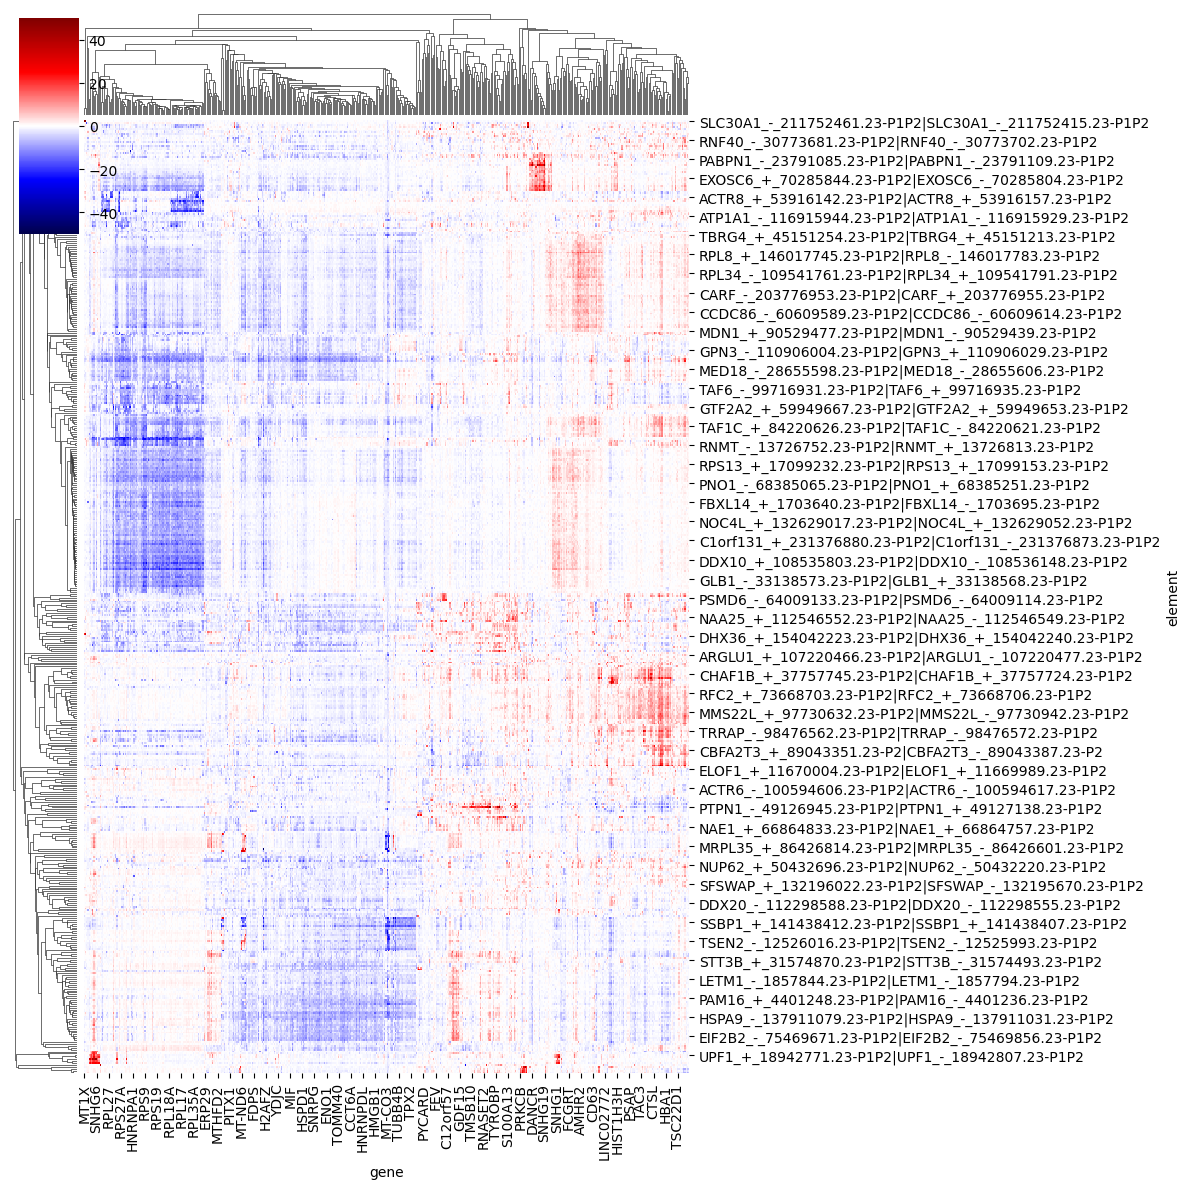

In [78]:
heatmap = sns.clustermap(plot_z_df, metric="cosine", cmap="seismic", dendrogram_ratio=0.1, vmin=-50, vmax=50, figsize=(12,12))
heatmap
# heatmap.savefig("gwps_plots/zscore_heatmap_full.png", dpi=300)

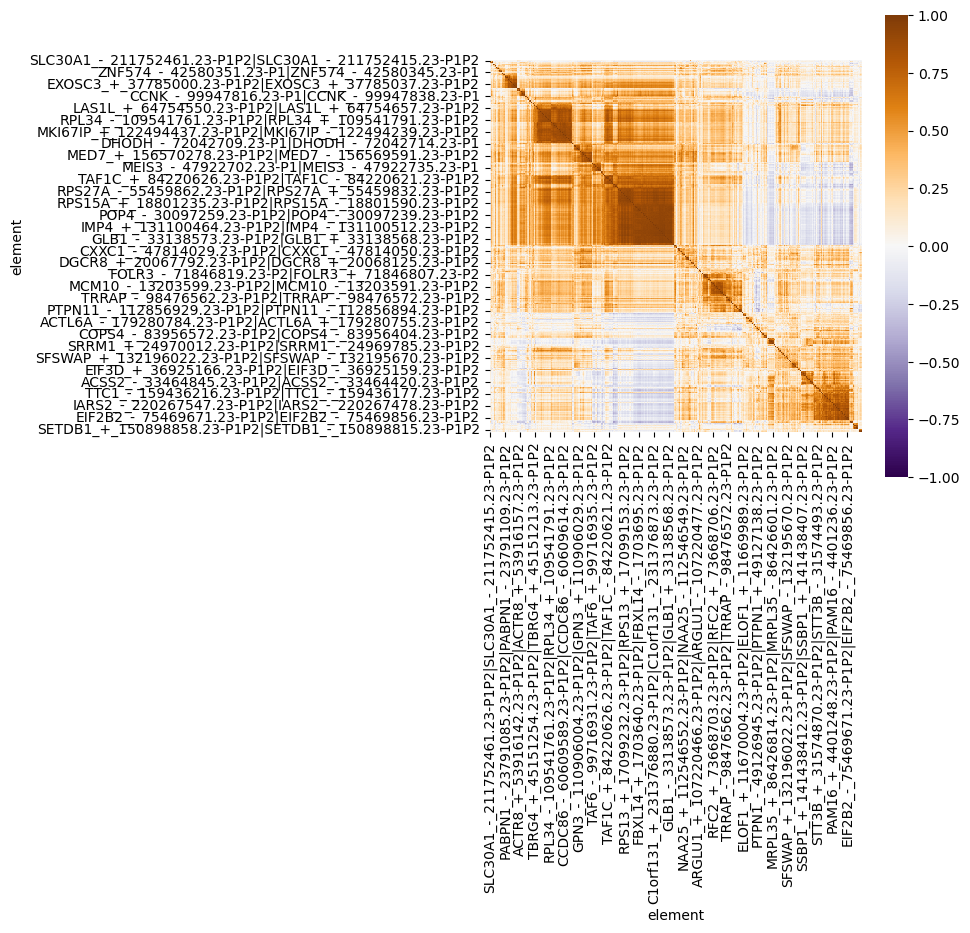

In [80]:
row_idx = heatmap.dendrogram_row.reordered_ind
f, ax = plt.subplots(figsize=(6, 6))
corr_heatmap = sns.heatmap(corr_df.iloc[row_idx,:].iloc[:,row_idx], cmap="PuOr_r", square=True, vmin=-1, vmax=1, ax=ax)
# f.savefig("gwps_plots/corr_heatmap.png", dpi=300)

In [86]:
gwps_df=gwps_df.assign(target = lambda x: x['element'].str.replace(r'_.*','', regex=True))
gwps_df

## Compare targeted gene knockdown vs. all other effects 

In [ ]:
gwps_df=gwps_df.assign(is_pos_crtl=lambda x: x['target']==x['gene'])
gwps_df.groupby('is_pos_crtl')['z_value'].mean()
# pos_ctrls = gwps_df.query("guide==gene").sort_values("z_value")
# sns.histplot(gwps_df, x='z_value', hue='is_pos_crtl', bins=100, stat="density", common_norm=False)
# sns.displot(gwps_df, x='z_value', hue='is_pos_crtl', common_norm=False)

# pos_ctrls
# plt.show()


In [ ]:
gwps_df=gwps_df.sort_values("z_value")
gwps_df.to_csv("K562_essential_raw_singlecell_01.csv")

In [ ]:
gwps_df

,guide,gene,z_value,is_pos_crtl
10895305,KRR1,RPS3,-38.388737,False
19434727,FASTKD5,MT-ATP6,-34.285698,False
6668300,RPS19,EEF1A1,-33.205326,False
12410384,WDR3,TPT1,-33.069458,False
17176379,RPS19,RPS19,-32.150661,True
...,...,...,...,...
2451348,NCBP2,PCBP1-AS1,49.571320,False
13897720,GAB2,HBZ,51.932728,False
14015874,EXOSC2,SNHG19,52.111626,False
14017453,ZFC3H1,SNHG19,53.986736,False
